In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [3]:
iris = load_iris()
wine = load_wine()

print("Iris Records:", iris.data.shape[0])
print("Iris Classes:", len(iris.target_names))
print("Iris Features:", iris.feature_names)

print("\nWine Records:", wine.data.shape[0])
print("Wine Classes:", len(wine.target_names))
print("Wine Features:", wine.feature_names)

Iris Records: 150
Iris Classes: 3
Iris Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Wine Records: 178
Wine Classes: 3
Wine Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [4]:
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42)

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    wine.data, wine.target, test_size=0.2, random_state=42)

In [5]:
svm_linear = SVC(kernel="linear")
svm_linear.fit(X_train_i, y_train_i)

y_pred_lin = svm_linear.predict(X_test_i)

print("Linear SVM Accuracy:", accuracy_score(y_test_i, y_pred_lin))
print("Support Vectors:", svm_linear.n_support_)

Linear SVM Accuracy: 1.0
Support Vectors: [ 3 11 11]


In [6]:
svm_rbf = SVC(kernel="rbf")
svm_rbf.fit(X_train_i, y_train_i)

y_pred_rbf = svm_rbf.predict(X_test_i)

print("RBF SVM Accuracy:", accuracy_score(y_test_i, y_pred_rbf))

RBF SVM Accuracy: 1.0


In [7]:
svm_rbf = SVC(kernel="rbf")
svm_rbf.fit(X_train_i, y_train_i)

y_pred_rbf = svm_rbf.predict(X_test_i)

print("RBF SVM Accuracy:", accuracy_score(y_test_i, y_pred_rbf))

RBF SVM Accuracy: 1.0


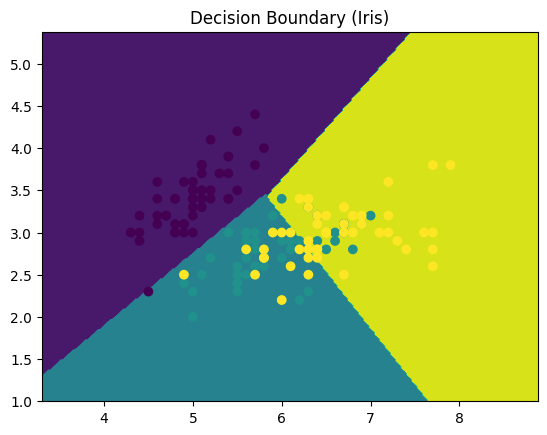

In [8]:
X = iris.data[:, :2]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = SVC(kernel='linear')
model.fit(X_train, y_train)

x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Decision Boundary (Iris)")
plt.show()

In [9]:
cm = confusion_matrix(y_test_i, y_pred_rbf)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n",
      classification_report(y_test_i, y_pred_rbf))

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [10]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_i, y_train_i)

y_pred_lr = lr.predict(X_test_i)

print("Logistic Accuracy:", accuracy_score(y_test_i, y_pred_lr))

Logistic Accuracy: 1.0


In [11]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_i, y_train_i)

y_pred_lr = lr.predict(X_test_i)

print("Logistic Accuracy:", accuracy_score(y_test_i, y_pred_lr))

Logistic Accuracy: 1.0


In [15]:
knn = KNeighborsClassifier()
knn.fit(X_train_i, y_train_i)

y_pred_knn = knn.predict(X_test_i)

print("k-NN Accuracy:", accuracy_score(y_test_i, y_pred_knn))

k-NN Accuracy: 1.0


In [16]:
data = {
    "Model": ["Logistic", "SVM Linear", "SVM RBF", "k-NN"],
    "Accuracy": [
        accuracy_score(y_test_i, y_pred_lr),
        accuracy_score(y_test_i, y_pred_lin),
        accuracy_score(y_test_i, y_pred_rbf),
        accuracy_score(y_test_i, y_pred_knn)
    ]
}

df = pd.DataFrame(data)
print(df)

        Model  Accuracy
0    Logistic       1.0
1  SVM Linear       1.0
2     SVM RBF       1.0
3        k-NN       1.0


In [17]:
# Conclusion:
# SVM performs well for both linear and non-linear data using different kernels.
# RBF kernel usually gives better accuracy than linear for complex datasets.
# Logistic Regression is faster and works well for simple data,
# while k-NN depends heavily on the choice of k.
# Overall, SVM is powerful but computationally expensive,
# and the best model depends on dataset complexity and problem requirements.